In [1]:
import matplotlib.pyplot as plt
import cv2 

from functions import *
from tumor_dataset import *

In [2]:
d = Dataset(data_path="../../data/raw_data/useable_data")

Init Dataset


In [3]:
# file paths 
im_raw = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_texture.jpg"
im_mask = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1.jpg"
im_bin = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1.bin"

In [4]:
# helper function 
def read_bin(file_path):
    """
    opens a binary file in a specific path and extracts the point cloud
    information from that. Returns lists of x, y, and z values

    Parameters
    ----------
    file_path : str
        file path to binary file

    Returns
    -------
    grid_x, grid_y, grid_z
        lists of floats that represent the point cloud of the tumor
    """

    with open(file_path, "rb") as fid:
        data = np.fromfile(fid, dtype=">f8")

    points = data.reshape(-1, 3)

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    grid_x, grid_y = np.meshgrid(
        np.linspace(min(x), max(x), 256), np.linspace(min(y), max(y), 256)
    )

    grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

    return grid_x, grid_y, grid_z


In [5]:
# some depth code 

x, y, z = read_bin(im_bin)
depth_info = []
depth_info.append((x, y, z, im_bin))

Saving Contour Plots:   0%|          | 0/1 [00:00<?, ?it/s]

Infusing Images: 100%|██████████| 1/1 [00:00<00:00, 1159.93it/s]


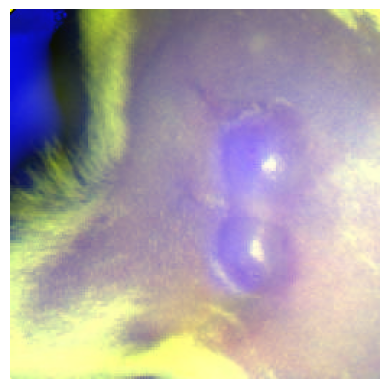

In [23]:
# file paths 
im_raw = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1_texture.jpg"
im_mask = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1.jpg"
im_bin = "/projects/PUCHALLA/LLP2024/tumor-segmentation/data/huggingface-repo/useable_data/013023 4T1 EpP + aPD1-aPD1 + EpP-1-1-218-1.bin"
# take sample image
im_raw = cv2.imread(im_raw)
im_mask = cv2.imread(im_mask)

im_raw = d.crop_raw_images([im_raw])
im_to_infuse = im_raw.copy()
im_mask = d.crop_masks([im_mask])
im_raw = d.read_contours_array_depth(depth_info)
im_raw = d.infuse_depth_into_blue_channel(im_to_infuse, im_raw)
im_raw, im_mask = d.add_padding(im_raw, im_mask)
# im_mask = d.zoom_at(im_mask, 1.333, coord=None)
# im_mask = d.create_binary_masks(im_mask)
im_raw = d.crop_images(im_raw)
# im_mask = d.crop_images_offset(im_mask, x_offset=-25)
# im_mask = d.correct_binary_masks(im_mask)

plt.axis("off")
plt.imshow(cv2.cvtColor(im_raw[0], cv2.COLOR_BGR2RGB))